In [3]:
# Test to load one pickle file
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from lameg.laminar import compute_csd
from lameg.viz import plot_csd

In [ ]:
filepath = '/home/sgailhard/Documents/laminar_meg/laminar_csd_method/simulations/2_double_dipole/1_simultaneous/cluster/sim_2_simult_sources_snr'
filename = 'vx27692_2_simult_sources_snr-20.pickle'

with open(os.path.join(filepath, filename), 'rb') as f:
    data = pickle.load(f)

In [7]:
data

{'sim_vertex': 27692,
 'sim_layers': [(0, 10), (3, 7)],
 'patch_size': 5,
 'err_level': 0,
 'sim_patch_size': 5,
 'n_temp_modes': 4,
 'n_spatial_modes': 68,
 'hann_windowing': False,
 'snr': -20,
 'dipole_moment': [5, 5],
 'sim_signal': array([[1.38124209e-22, 1.92874985e-22, 2.69029223e-22, ...,
         5.21673666e-22, 3.74835280e-22, 2.69029223e-22],
        [1.38124209e-22, 1.92874985e-22, 2.69029223e-22, ...,
         5.21673666e-22, 3.74835280e-22, 2.69029223e-22]]),
 'win_size': 25,
 'woi': [-10.333333333333295, 13.666666666666705],
 'sfreq': 600,
 'thickness': 2.2992003,
 'time': array([-500.        , -498.33333333, -496.66666667, -495.        ,
        -493.33333333, -491.66666667, -490.        , -488.33333333,
        -486.66666667, -485.        , -483.33333333, -481.66666667,
        -480.        , -478.33333333, -476.66666667, -475.        ,
        -473.33333333, -471.66666667, -470.        , -468.33333333,
        -466.66666667, -465.        , -463.33333333, -461.66666667

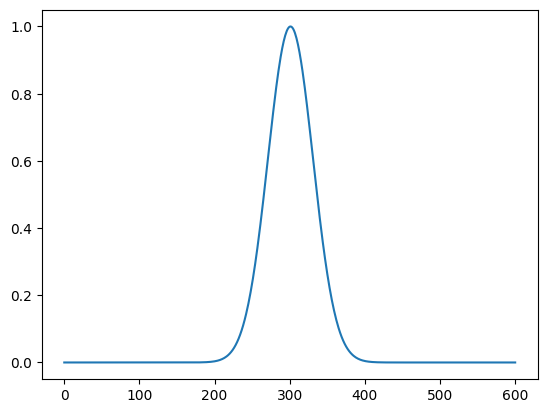

In [11]:
# plot the sim signal
plt.plot(data["sim_signal"][0])

In [12]:
data.keys()

dict_keys(['sim_vertex', 'sim_layers', 'patch_size', 'err_level', 'sim_patch_size', 'n_temp_modes', 'n_spatial_modes', 'hann_windowing', 'snr', 'dipole_moment', 'sim_signal', 'win_size', 'woi', 'sfreq', 'thickness', 'time', 'ts_ebb', 'ts_ebb_layer', 'fs', 'fid_coords'])

In [40]:
n_layers = data["fs"].shape[1]

In [ ]:
# get the relative free energy 
fs_matrix = data['fs']      # (n_rows, 11, 11)
relativeFs = np.array([
        fs_matrix[sim_idx, :] - fs_matrix[sim_idx, :].min()
        for sim_idx in range(fs_matrix.shape[0])
    ])

In [ ]:
relativeFs.shape #(n_sim, n_layers)

(2, 11)

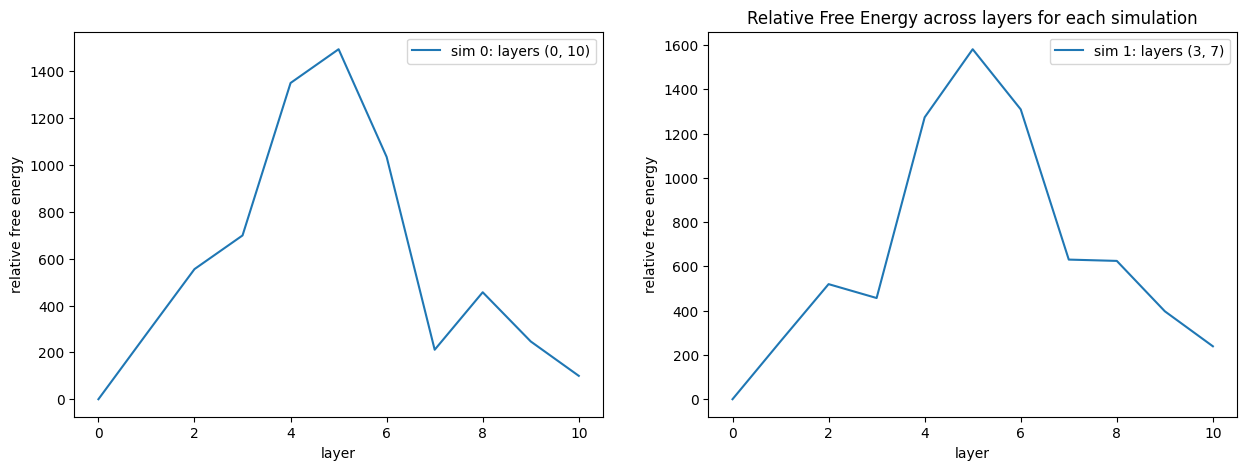

In [33]:
fig, ax = plt.subplots(1, relativeFs.shape[0], figsize=(15, 5))
for i in range(relativeFs.shape[0]):
    ax[i].plot(relativeFs[i, :], label=f'sim {i}: layers {data["sim_layers"][i]}')
    ax[i].set_xlabel('layer')
    ax[i].set_ylabel('relative free energy')
    ax[i].legend()
plt.title('Relative Free Energy across layers for each simulation')
plt.show()

In [ ]:
# get the ebb matrix
sfreq = data['sfreq']
thickness = data['thickness']
ebb_matrix = data['ts_ebb']      # (n_sim, n_layers)
csd_ebb = np.array([
        compute_csd(ebb_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01


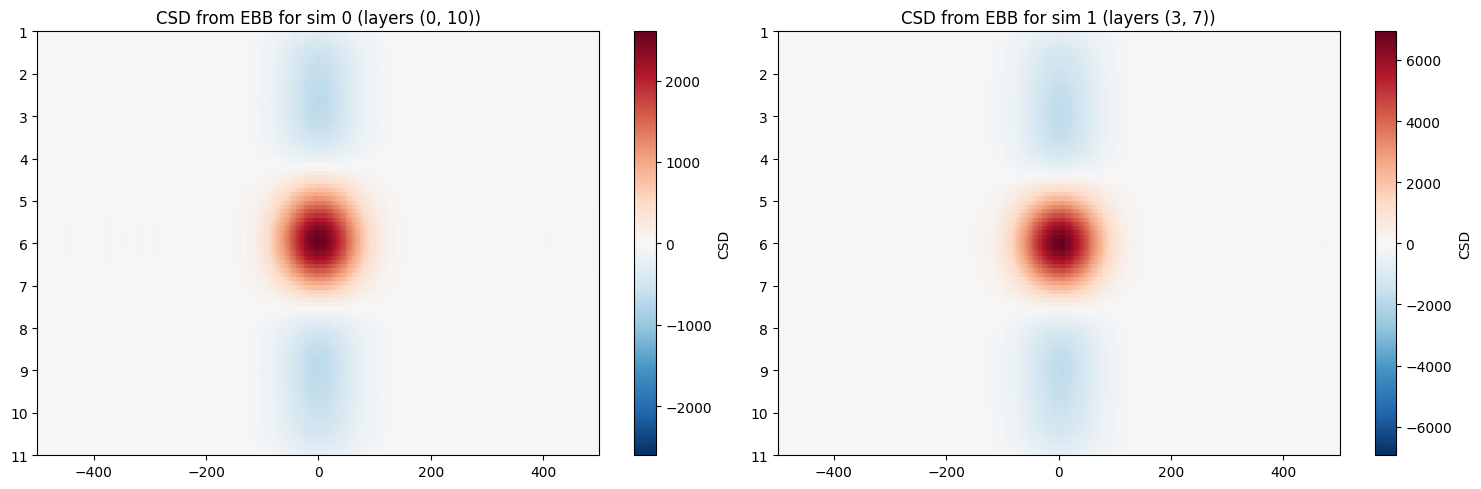

In [32]:
fig, ax = plt.subplots(1, csd_ebb.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb.shape[0]):
    plot_csd(csd_ebb[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')

In [21]:
# get the ebb_layer matrix
ebb_layer_matrix = data['ts_ebb_layer']      # (n_sim, n_layers)
csd_ebb_layer = np.array([
        compute_csd(ebb_layer_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_layer_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092


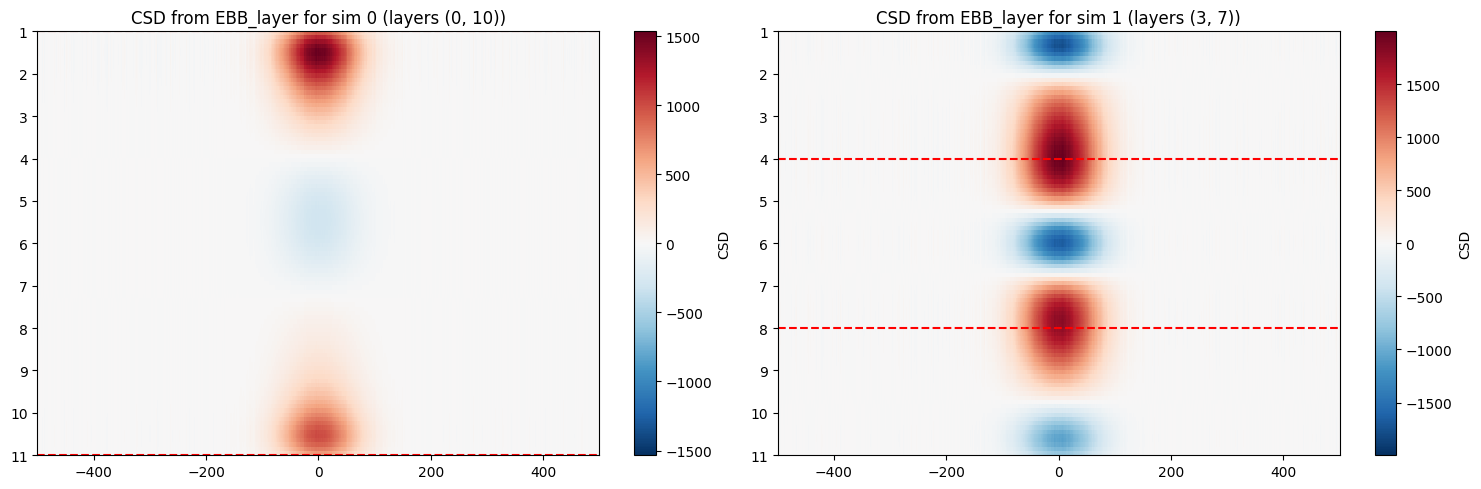

In [46]:
fig, ax = plt.subplots(1, csd_ebb_layer.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb_layer.shape[0]):
    plot_csd(csd_ebb_layer[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    for layer in data["sim_layers"][sim_idx]:
        ax[sim_idx].axhline(layer/(n_layers-1), color='red', linestyle='--')